In [1]:
# Reading the files for kde

import pandas as pd

files = 8
xy_data = []

for i in range(1, files + 1):
    filename = f"xy_part_{i}.csv"
    df_part = pd.read_csv(filename, header=0, names=['x', 'y'])
    xy_data.append(df_part)

df = pd.concat(xy_data, ignore_index=True)

In [2]:
df_ini = pd.read_csv('ini_state_q1.csv', header=0, names = ['x','y','rad','part'], delimiter='\t')
xy_circle = df_ini[df_ini['part']==0][['x','y']]
circle_tuples = list(xy_circle.itertuples(index=False, name=None))
center_x = 15.0
center_y = 15.0
radius = 15

/tmp/ipykernel_476068/280919425.py:3: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 1.23.4)
  from scipy.stats import gaussian_kde
/home/pallab_workstation/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


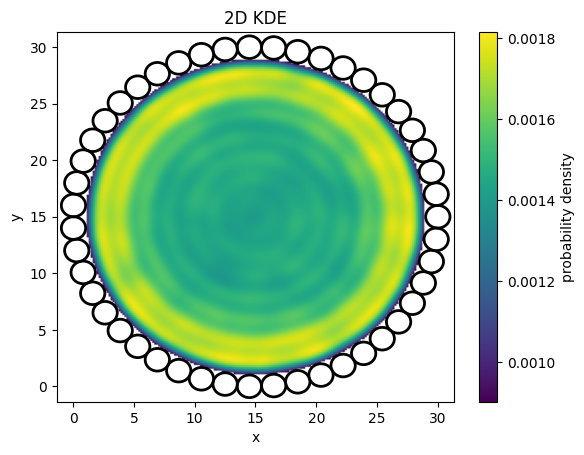

In [3]:
# plotting kde using scipy - gaussian kde

from scipy.stats import gaussian_kde
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

sample_size = 250000
sample_df = df.sample(n=sample_size, random_state=123) 

# Extract sample data
x = sample_df['x'].values
y = sample_df['y'].values

# Create a regular grid to evaluate KDE
extra = 3.0
xmin, xmax = x.min()-extra, x.max()+extra
ymin, ymax = y.min()-extra, y.max()+extra
X, Y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([x, y])

# Compute KDE values
kde = gaussian_kde(values)
Z = np.reshape(kde.evaluate(positions), X.shape)

grid_range = np.sqrt((X-center_x)**2+(Y-center_y)**2)
Z_masked = np.where(grid_range<=(radius-1), Z, np.nan)

plt.imshow(Z_masked.T, origin='lower', aspect='auto', extent=[xmin, xmax, ymin, ymax],
           cmap='viridis')

ax = plt.gca()
for(cx,cy) in circle_tuples:
    circle = patches.Circle((cx,cy),radius=1.0, edgecolor='black', facecolor='none', linewidth=2)
    ax.add_patch(circle)
    
plt.colorbar(label="probability density")
plt.title("2D KDE")
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f"kde_passive_sample_{sample_size}.png")
plt.savefig(f"kde_passive_sample_{sample_size}.eps")